In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from input_pipeline import preprocess_dataset, mask_dataset, batch_sampler
from models.median_baseline import median_baseline
import xarray as xr
import jax.numpy as jnp
import jax
import chex
import numpy as np
import flax
import rich
import flax.linen as nn
import optax

### Load, Normalization & Masking

In [3]:
ds = xr.load_dataarray('../data/SiC_19x10x3.nc')
filtered_ds = preprocess_dataset(ds, verbose = True)
mask_window: tuple = (1525, 1650)
attn_mask = ~(
        (filtered_ds.wave_number < mask_window[1]) & (filtered_ds.wave_number > mask_window[0])
    ).values
masked_ds = mask_dataset(filtered_ds, mask_window=mask_window)

Dropped 0 spectra


In [4]:
# Transformer model. See "Formal algorithms for transformers" [arXiv:2207.09238 [cs.LG]] and "On Layer Normalization in the Transformer Architecture" [arXiv:2002.04745 [cs.LG]] and "An introduction to transformers" [arXiv:2304.10557 [cs.LG]].

class LinearProjection(nn.Module):
    """Linear embedding projection"""
    embedding_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(self.embedding_dim, use_bias=False)(x)
        x = nn.LayerNorm()(x)
        return x
    
def test_LinearProjection():
    """Test LinearProjection"""
    x = np.random.randn(1, 2, 3, 100)
    model = LinearProjection(128)
    variables = model.init(jax.random.PRNGKey(0), x)
    y = model.apply(variables, x)
    chex.assert_shape(y, (1,2,3,128))
    chex.assert_shape(variables['params']['Dense_0']['kernel'], (100, 128))
test_LinearProjection()

class FFBlock(nn.Module):
    """Feed-forward block for transformer model"""
    embedding_dim: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        x = nn.Dense(4*self.embedding_dim)(x)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic = not training)(x)
        x = nn.Dense(self.embedding_dim)(x)
        return x
    
class MLP(nn.Module):
    """Multi-layer perceptron"""
    embedding_dim: int
    num_layers: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        for _ in range(self.num_layers):
            x = FFBlock(self.embedding_dim, self.dropout_rate)(x, training = training)
        return x

class TransformerEncoderLayer(nn.Module):
    """Transformer encoder layer"""
    embedding_dim: int
    num_heads: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, attn_mask, training: bool):
        # Multi-head attention
        x_norm = nn.LayerNorm()(x)
        x_norm = nn.MultiHeadDotProductAttention(
            num_heads = self.num_heads,
            qkv_features = self.embedding_dim
        )(x_norm, mask=attn_mask, deterministic = not training)
        x = x + nn.Dense(self.embedding_dim)(x_norm) # Residual connection
        x_norm = nn.LayerNorm()(x)
        x_norm = FFBlock(self.embedding_dim, self.dropout_rate)(x_norm, training = training)
        x = x + nn.Dense(self.embedding_dim)(x_norm)
        return x
    
class SpectraFormer(nn.Module):
    embedding_dim: int
    num_heads: int
    num_layers: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, counts, wave_number, wave_number_mask, training: bool = True):
        #wave_number_mask is a 1D boolean array of shape num_wave_numbers
        emb_counts = LinearProjection(self.embedding_dim)(counts) # [batch_size, num_wave_numbers, 1]
        emb_wave_number = LinearProjection(self.embedding_dim)(wave_number) # [num_wave_numbers, 1]
        x = emb_counts + emb_wave_number # [batch_size, num_wave_numbers, embedding_dim]
        attn_mask = nn.make_attention_mask(wave_number_mask, wave_number_mask, extra_batch_dims=x.ndim - 2)
        for _ in range(self.num_layers):
            x = TransformerEncoderLayer(self.embedding_dim, self.num_heads, self.dropout_rate)(x, attn_mask, training = training)
        x = nn.LayerNorm()(x)
        x = nn.Dense(1)(x)
        return x

In [5]:
from flax.training import train_state
class TrainState(train_state.TrainState):
  key: jax.Array

In [6]:
@jax.jit
def train_step(state: TrainState, batch, dropout_key):
  dropout_train_key = jax.random.fold_in(key=dropout_key, data=state.step)
  def loss_fn(params):
    pred_spectra = state.apply_fn(
      {'params': params},
      batch['masked_spectra'], batch['wave_number'], attn_mask,
      training=False, # Disable dropout for the moment
      rngs={'dropout': dropout_train_key}
      )
    loss = optax.squared_error(pred_spectra, batch['spectra']).mean()
    return loss
  grad_fn = jax.value_and_grad(loss_fn)
  loss, grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss

In [17]:
model = SpectraFormer(embedding_dim = 32, num_heads = 4, num_layers = 4)
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

dummy_batch = next(batch_sampler(filtered_ds, masked_ds))
variables = model.init(params_key, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'], attn_mask, training = False)
params = variables['params']

state = TrainState.create(
  apply_fn=jax.jit(model.apply, static_argnames=('training', 'capture_intermediates')),
  params=params,
  key=dropout_key,
  tx=optax.adam(1e-4)
)

from tqdm import tqdm
n_epochs = 100
train_loss = []

In [18]:
tabulate_fn = nn.tabulate(model, jax.random.key(0), depth = 1, console_kwargs={'force_jupyter': True})

In [19]:
print(tabulate_fn(dummy_batch['masked_spectra'][0], dummy_batch['wave_number'], attn_mask, training = False))

                                               SpectraFormer Summary                                               
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module                ┃ inputs                ┃ outputs          ┃ params               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ SpectraFormer         │ - float32[1015,1]     │ float32[1015,1]  │                      │
│                       │                       │ - float32[1015,1]     │                  │                      │
│                       │                       │ - bool[1015]          │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_0    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 98 (392 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LinearProjection_1    │ LinearProjection      │ float32[1015,1]       │ float32[1015,32] │ 98 (392 B)           │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ TransformerEncoderLa… │ TransformerEncoderLa… │ - float32[1015,32]    │ float32[1015,32] │ 14,816 (59.3 KB)     │
│                       │                       │ -                     │                  │                      │
│                       │                       │ float32[1,1015,1015]  │                  │                      │
│                       │                       │ - training: False     │                  │                      │
├───────────────────────┼───────────────────────┼───────────────────────┼──────────────────┼──────────────────────┤
│ LayerNorm_0           │ LayerNorm             │ float32[1015,32]      │ float32[1015,32] │ bias: float32[32]    │
│                       │                       │       

In [20]:
test_batch = next(batch_sampler(filtered_ds, masked_ds, batch_size = 1))

In [22]:
res = state.apply_fn({'params': state.params}, test_batch['masked_spectra'], test_batch['wave_number'], attn_mask, training = False, capture_intermediates=True)

In [31]:
test_batch['wave_number']

Array([[1278.2969],
       [1279.998 ],
       [1281.6973],
       ...,
       [2817.6982],
       [2819.0596],
       [2820.421 ]], dtype=float32)

In [29]:
res[1]['intermediates']

{'Dense_0': {'__call__': (Array([[[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]]], dtype=float32),)},
 'LayerNorm_0': {'__call__': (Array([[[0., 0., 0., ..., 0., 0., 0.],
           [0., 0., 0., ..., 0., 0., 0.],
           [0., 0., 0., ..., 0., 0., 0.],
           ...,
           [0., 0., 0., ..., 0., 0., 0.],
           [0., 0., 0., ..., 0., 0., 0.],
           [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),)},
 'LinearProjection_0': {'Dense_0': {'__call__': (Array([[[ 0., -0., -0., ...,  0.,  0.,  0.],
            [ 0., -0., -0., ...,  0.,  0.,  0.],
            [ 0., -0., -0., ...,  0.,  0.,  0.],
            ...,
            [ 0., -0., -0., ...,  0.,  0.,  0.],
            [ 0., -0., -0., ...,  0.,  0.,  0.],
            [ 0., -0., -0., ...,  0.,  0.,  0.]]], dtype=float32),)},
  'LayerNorm_0': {'__call__': (Array([[[0.],
            [0.],
            [0.],
            ...,
            [0.],
            [0.],
           

In [26]:
for epoch in tqdm(range(n_epochs)):
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = 16, shuffle = True, drop_last = True, rng_seed = epoch)
    for batch in train_iter:
        state, _loss = train_step(state, batch, dropout_key)
        train_loss.append(_loss.item())

  0%|          | 0/100 [00:00<?, ?it/s]

 78%|███████▊  | 78/100 [02:01<00:34,  1.56s/it]


KeyboardInterrupt: 

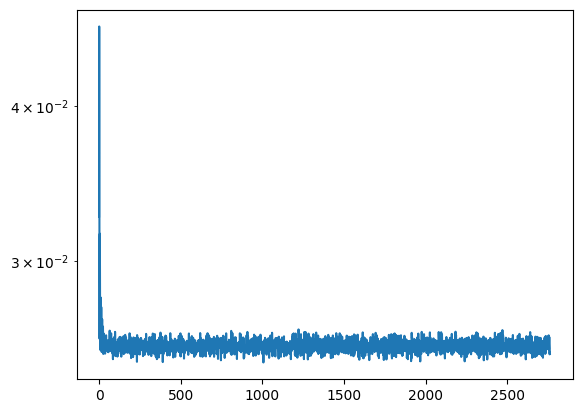

In [27]:
import matplotlib.pyplot as plt
plt.plot(train_loss)
plt.yscale('log')

In [36]:
def predict(apply_fn, params, spectra, wave_number):
    import pandas as pd
    pred_SiC = apply_fn(params, spectra, wave_number, attn_mask, training = False)
    pred_Graphene = spectra - pred_SiC
    res = {k: v[:, 0] for k, v in {'SiC': pred_SiC, 'Graphene': pred_Graphene, 'Total': spectra, 'Wave number': wave_number}.items()}
    
    return pd.DataFrame(res)

In [38]:
result = predict(state.apply_fn, {'params': state.params}, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'])

In [40]:
result

,SiC,Graphene,Total,Wave number
0,0.086575,-0.042825,0.043750,1278.296875
1,0.086575,-0.036086,0.050489,1279.998047
2,0.086575,-0.049517,0.037058,1281.697266
3,0.086575,-0.029325,0.057250,1283.396484
4,0.086575,-0.046797,0.039778,1285.095703
...,...,...,...,...
1010,0.086575,-0.084192,0.002384,2814.975586
1011,0.086575,-0.089222,-0.002647,2816.336914
1012,0.086575,-0.097614,-0.011038,2817.698242
1013,0.086575,-0.077455,0.009120,2819.059570


<Axes: xlabel='Wave number'>

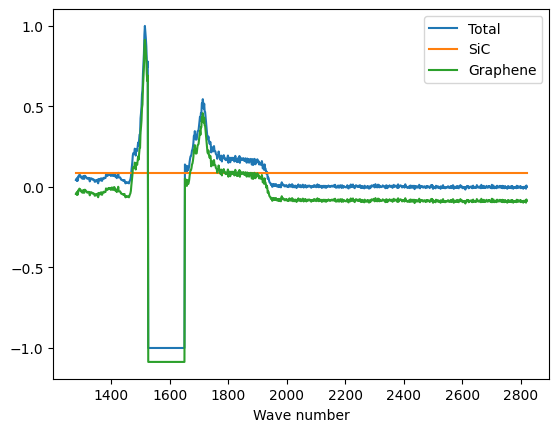

In [39]:
result.plot(x="Wave number", y=["Total", "SiC", "Graphene"])

In [9]:
from time import perf_counter

# Measure throughput at different batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256]

for batch_size in batch_sizes:
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
    rng = jax.random.PRNGKey(0)
    rng, init_rng = jax.random.split(rng)
    batch = next(train_iter)
    variables = model.init(init_rng, counts = batch['masked_spectra'][0], wave_number = batch['wave_number'][0], training = False)
    # Warmup
    apply_fn = jax.jit(model.apply, static_argnames='training')
    apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
    
    # Measure throughput
    times = []
    for batch in train_iter:
        _dt = perf_counter()
        out = apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
        _dt = perf_counter() - _dt
        times.append(_dt)
    times = np.array(times)
    print(f"Batch size: {batch_size}, throughput: {batch_size / times.mean():.0f} samples/s")

Batch size: 8, throughput: 18170 samples/s
Batch size: 16, throughput: 29596 samples/s
Batch size: 32, throughput: 17774 samples/s
Batch size: 64, throughput: 16471 samples/s
Batch size: 128, throughput: 13481 samples/s
Batch size: 256, throughput: 19556 samples/s
